# 从 Transformer Block 到 Mini-GPT

> 上一节我们把 Attention、FFN、Residual、LayerNorm 组装成了 Transformer Block。一个 Block 只有一层，能力有限。把多个 Block 堆叠起来，前后接上 Embedding 和输出投影，就构成了一台完整的 GPT。
>
> 这一节从零搭建一台 Mini-GPT，跑通前向传播，再对照 Karpathy 的 nanoGPT 确认结构一致。

GPT（Generative Pre-trained Transformer）是一类 decoder-only（只有解码器）的语言模型，核心思路是：给定一段文本的前缀，预测下一个 token。输入先经过 Embedding 查表和位置编码，再经过多层 Transformer Block，最后用一个线性层把每个位置的隐藏向量投影到词表大小，得到一组分数，称为 logits。logits 经过 softmax 或采样策略之后，就能得到模型认为最可能接在后面的 token。

In [ ]:
# 不依赖 transformers，直接用 GPT-2 Small 的公开配置做参数量手算
gpt2_config = {
    "vocab_size": 50257,
    "n_positions": 1024,
    "n_embd": 768,
    "n_layer": 12,
    "n_head": 12,
}

vocab_size = gpt2_config["vocab_size"]
n_positions = gpt2_config["n_positions"]
n_embd = gpt2_config["n_embd"]
n_layer = gpt2_config["n_layer"]
n_head = gpt2_config["n_head"]
d_ff = 4 * n_embd

wte_params = vocab_size * n_embd
wpe_params = n_positions * n_embd
ln_params = 2 * n_embd

# GPT-2 的 attention: c_attn 一次性算 Q/K/V，再接 c_proj。
attn_params = n_embd * (3 * n_embd) + (3 * n_embd)
attn_params += n_embd * n_embd + n_embd

# GPT-2 的 MLP: 先扩到 4 倍维度，再压回 n_embd。
mlp_params = n_embd * d_ff + d_ff
mlp_params += d_ff * n_embd + n_embd

layer_total = ln_params + attn_params + ln_params + mlp_params
ln_f_params = 2 * n_embd
total_unique_params = wte_params + wpe_params + n_layer * layer_total + ln_f_params

print("=== GPT-2 Small 配置（公开结构参数）===")
print(f"词表大小:     {vocab_size}")
print(f"隐藏维度:     {n_embd}")
print(f"层数:         {n_layer}")
print(f"注意力头数:   {n_head}")
print(f"最大序列长度: {n_positions}")
print()

print("=== GPT-2 Small 参数量手算 ===")
print(f"Token Embedding (wte):       {wte_params:>10,}")
print(f"Position Embedding (wpe):    {wpe_params:>10,}")
print(f"每层 LayerNorm 1:            {ln_params:>10,}")
print(f"每层 Attention:              {attn_params:>10,}")
print(f"每层 LayerNorm 2:            {ln_params:>10,}")
print(f"每层 MLP:                    {mlp_params:>10,}")
print(f"每层合计:                    {layer_total:>10,}")
print(f"Final LayerNorm:             {ln_f_params:>10,}")
print(f"LM Head 额外参数:            {0:>10,}  ← GPT-2 与 wte 权重共享")
print(f"{'-' * 55}")
print(f"总参数量（不重复计算共享权重）: {total_unique_params:>10,}")

print()
print("关键观察：GPT-2 和 MiniGPT 的骨架一致，但 GPT-2 还用了可学习位置编码和权重共享。")


先把 GPT-2 和原始 Transformer 的差别画清楚。GPT-2 只保留 Decoder 主干，用来不断预测下一个 token；它没有 Encoder，也没有 Cross-Attention。

```text
GPT-2 / Decoder-Only

Token IDs
  ↓
Token Embedding + Position Embedding
  ↓
Masked Self-Attention   ← 只能看当前位置及之前的 token
  ↓
Feed-Forward Network
  ↓
重复很多层 Decoder Block
  ↓
LM Head
  ↓
预测下一个 token
```

作为对比，原始 Transformer 是 Encoder-Decoder 结构，常用于翻译这类「先读输入，再生成输出」的任务：

```text
原始 Transformer / Encoder-Decoder

输入句子 → Encoder → Encoder 输出
                         ↓
目标前缀 → Decoder → Cross-Attention 读取 Encoder 输出
                         ↓
                      生成下一个 token
```

将两张图对比来看：原始 Transformer 的 Decoder 有两类 Attention——Masked Self-Attention（看自己的前缀）和 Cross-Attention（看 Encoder 的输出）。GPT-2 只有 Masked Self-Attention，因为它是纯生成模型，没有 Encoder。

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import time

import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)


## 1. GPT 的整体结构

GPT 的数据流可以看成一条流水线。输入是 token ID 序列，输出是每个位置对整个词表的预测分数：

```text
Token IDs
  ↓
Token Embedding + Position Embedding
  ↓
Transformer Block × N
  ↓
LayerNorm
  ↓
Linear（投影到词表大小）
  ↓
logits：每个位置预测下一个 token
```

这条流水线里，中间的维度一直保持 `d_model` 不变，只有最后一步才展开成 `vocab_size`。用 shape 来看就是：

```text
[batch, seq] → [batch, seq, d_model] → ... → [batch, seq, vocab_size]
```

接下来沿着这条流水线，一步一步实现。

## 2. 复用 Transformer Block

为了让本 Notebook 单独运行，先把上一节的三个零件放在这里。

这里不重新解释每一行的原理，只记住它们的职责：

1. `MultiHeadAttention`：让 token 看见当前位置及之前的上下文。
2. `FeedForward`：每个 token 自己过一个小网络。
3. `TransformerBlock`：把 Attention、FFN、Residual、LayerNorm 串起来。

In [2]:
class MultiHeadAttention(nn.Module):
    """
    多头自注意力；传入 causal mask 时就是因果自注意力。
    
    参数:
        d_model: 输入/输出维度
        num_heads: 注意力头数
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0, "d_model 必须能被 num_heads 整除"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # 每个头的维度
        
        # Q、K、V 的线性变换（把 num_heads 个头合并到矩阵操作里）
        self.W_Q = nn.Linear(d_model, d_model)
        self.W_K = nn.Linear(d_model, d_model)
        self.W_V = nn.Linear(d_model, d_model)
        
        # 输出投影
        self.W_O = nn.Linear(d_model, d_model)
    
    def forward(self, x, mask=None):
        """
        输入: x shape = [batch, seq_len, d_model]
        输出:   shape = [batch, seq_len, d_model]
        """
        batch_size, seq_len, _ = x.shape
        
        # 1. 线性变换 + 拆成多头
        #    [batch, seq_len, d_model] → [batch, num_heads, seq_len, d_k]
        Q = self.W_Q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_K(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_V(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # 2. 注意力分数: Q @ K^T
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(self.d_k)
        
        # 3. Mask（例如把未来的位置设为 -inf）
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))
        
        # 4. Softmax
        weights = F.softmax(scores, dim=-1)
        
        # 5. 加权求和
        attn_output = weights @ V  # [batch, num_heads, seq_len, d_k]
        
        # 6. 拼回头并投影
        attn_output = attn_output.transpose(1, 2).contiguous()
        attn_output = attn_output.view(batch_size, seq_len, self.d_model)
        return self.W_O(attn_output)


In [3]:
class FeedForward(nn.Module):
    """FFN：两层全连接，先扩 4 倍再压回"""
    def __init__(self, d_model, d_ff=None):
        super().__init__()
        d_ff = d_ff or 4 * d_model
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
    
    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))


class TransformerBlock(nn.Module):
    """一个 Transformer 解码器层：Attention + FFN，各带残差 + LayerNorm"""
    def __init__(self, d_model, num_heads, d_ff=None):
        super().__init__()
        self.attention = MultiHeadAttention(d_model, num_heads)
        self.ffn = FeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
    
    def forward(self, x, mask=None):
        x = self.norm1(x + self.attention(x, mask))  # Attention + 残差 + Norm
        x = self.norm2(x + self.ffn(x))              # FFN + 残差 + Norm
        return x


## 3. MiniGPT 的实现

上一节已经确认，Transformer Block 接收 `[batch, seq, d_model]` 的输入，输出同样的形状——它做的是"同维度变换"，在不改变形状的前提下融合上下文信息。现在要做的是把输入端和输出端接上去，形成一台完整的模型。

**第一步：Token Embedding。** 输入序列是一组整数 token ID，比如 `[5, 12, 3]`。整数本身没有语义信息（ID 为 12 的 token 并不"大于"ID 为 3 的 token），所以需要通过一张 Embedding 表，把每个 ID 映射成 `d_model` 维的向量。这一步在 notebook 03 中已经实现过。

**第二步：Position Encoding。** 同一个 token 出现在第 1 个位置和第 10 个位置，含义可能不同。Self-Attention 本身没有位置信息（它只看 token 之间的关系），所以需要在 Embedding 之后加上位置编码，让模型知道"这个向量来自序列的第几个位置"。这里复用上一节（notebook 04）的 sinusoidal position encoding。

**第三步：多层 Transformer Block。** Embedding 加上 Position 之后的数据，依次经过 N 个 Transformer Block。每个 Block 都在做同一件事：让 token 互相看、再各自加工。多层堆叠的效果是信息逐层融合——第一层可能学到相邻词的关系，更深的层可能捕捉更远、更抽象的依赖。

**最后一步：输出投影。** 经过 N 层 Block 之后，每个位置得到一个 `d_model` 维的向量。最后用一个线性层把它投影到词表大小 `vocab_size`，得到 `logits`——每个位置对词表中每个 token 的打分。

In [4]:
# 复用上一节的正弦位置编码
def get_sinusoidal_encoding(seq_len, d_model):
    position = torch.arange(seq_len).unsqueeze(1)
    div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe = torch.zeros(seq_len, d_model)
    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)
    return pe


class MiniGPT(nn.Module):
    """Mini GPT: Embedding → N×TransformerBlock → LayerNorm → 投影到词表"""
    def __init__(self, vocab_size, d_model=64, num_heads=4, num_layers=4, max_seq_len=128):
        super().__init__()
        self.d_model = d_model
        self.token_emb = nn.Embedding(vocab_size, d_model)
        pe = get_sinusoidal_encoding(max_seq_len, d_model)
        self.register_buffer('pe', pe)
        
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads) for _ in range(num_layers)
        ])
        self.ln_final = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)  # 投影到词表 → logits
    
    def forward(self, x):
        # x: [batch, seq_len]  token IDs
        batch_size, seq_len = x.shape
        x = self.token_emb(x) + self.pe[:seq_len, :]          # Embedding + Position
        mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        mask = mask.view(1, 1, seq_len, seq_len)
        for block in self.blocks:
            x = block(x, mask)
        x = self.ln_final(x)
        return self.lm_head(x)  # [batch, seq_len, vocab_size]

## 4. 前向传播的数据流

模型定义好了，接下来用一组随机数据跑一次前向传播。

模型尚未训练，输出的 logits 没有实际意义。这一步只关注数据是否按预期结构流动：输入的形状是 `[batch, seq]`，中间保持 `[batch, seq, d_model]`，最终输出 `[batch, seq, vocab_size]`。

In [5]:
# 测试 MiniGPT
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=64, num_heads=4, num_layers=2)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"总参数量: {total_params:,}, 可训练: {trainable_params:,}")

# 前向传播: batch=2, seq_len=8
batch_input = torch.randint(0, vocab_size, (2, 8))
logits = model(batch_input)
print(f"\n输入: {batch_input.shape}  →  输出: {logits.shape}")
print(f"输出 = [batch=2, seq=8, vocab={vocab_size}] → 每个位置对每个词的 logits")
print(f"logits[0, 7, :5]: {logits[0, 7, :5].tolist()}  ← 样本 0 位置 7 预测下一 token 的分数")

总参数量: 103,966, 可训练: 103,966

输入: torch.Size([2, 8])  →  输出: torch.Size([2, 8, 30])
输出 = [batch=2, seq=8, vocab=30] → 每个位置对每个词的 logits
logits[0, 7, :5]: [1.4079980850219727, -0.3056167960166931, -1.065438985824585, 0.11685330420732498, 0.531089186668396]  ← 样本 0 位置 7 预测下一 token 的分数


In [6]:
# 跟着结构图跑一次：每一步都打印 shape
vocab_size = 30
model = MiniGPT(vocab_size=vocab_size, d_model=32, num_heads=4, num_layers=2, max_seq_len=16)
idx = torch.randint(0, vocab_size, (2, 6))

with torch.no_grad():
    token_vec = model.token_emb(idx)
    pos_vec = model.pe[:idx.shape[1], :]
    x = token_vec + pos_vec
    print(f"1. token + position: {x.shape}")

    mask = torch.tril(torch.ones(idx.shape[1], idx.shape[1]))
    mask = mask.view(1, 1, idx.shape[1], idx.shape[1])

    for block_id, block in enumerate(model.blocks, start=1):
        x = block(x, mask)
        print(f"2.{block_id} 经过 TransformerBlock: {x.shape}")

    x = model.ln_final(x)
    logits = model.lm_head(x)
    print(f"3. logits: {logits.shape}")

print("关键观察：中间一直是 d_model 维，只有最后一步才变成 vocab_size。")


1. token + position: torch.Size([2, 6, 32])
2.1 经过 TransformerBlock: torch.Size([2, 6, 32])
2.2 经过 TransformerBlock: torch.Size([2, 6, 32])
3. logits: torch.Size([2, 6, 30])
关键观察：中间一直是 d_model 维，只有最后一步才变成 vocab_size。


### 用 PyTorch 看清模型结构

实际写 PyTorch 模型时，第一件事不是急着训练，而是确认每个组件的 shape 和参数量。

这里不用额外的结构摘要工具，只用 PyTorch 自带的 `named_children()` 和一次前向传播，打印 MiniGPT 的主要组件。重点观察三件事：Embedding 如何把 ID 变成向量，TransformerBlock 如何保持 `d_model` 不变，最后 `lm_head` 如何投影到词表大小。

In [ ]:
def count_params(module):
    """统计一个 PyTorch 模块里的参数数量"""
    return sum(p.numel() for p in module.parameters())

summary_model = MiniGPT(vocab_size=30, d_model=32, num_heads=4, num_layers=2, max_seq_len=16)
summary_input = torch.randint(0, 30, (2, 6))

print("=== MiniGPT 主要组件 ===")
for name, module in summary_model.named_children():
    params = count_params(module)
    print(f"{name:10s} | {module.__class__.__name__:16s} | params={params:,}")

with torch.no_grad():
    token_vec = summary_model.token_emb(summary_input)
    logits = summary_model(summary_input)

print()
print(f"输入 token IDs:       {tuple(summary_input.shape)}")
print(f"Embedding 输出:       {tuple(token_vec.shape)}")
print(f"MiniGPT 最终 logits:  {tuple(logits.shape)}")
print()
print("关键观察：Embedding 把 [batch, seq] 变成 [batch, seq, d_model]。")
print("中间的 TransformerBlock 保持 d_model 不变，最后 lm_head 才投影到 vocab_size。")


## 5. Logits 和预测

上一节的代码输出了一个叫 logits 的张量，形状是 `[batch, seq, vocab_size]`。这一节解释它是什么。

logits 是模型最后输出的原始分数。如果词表有 30 个 token，那么每个位置都会输出 30 个分数：

```text
logits[batch, 位置, token_id]
```

分数越高，模型越认为这个 token 适合作为"下一个 token"。举个例子，如果 `logits[0, 7, 12] = 2.3` 是位置 7 上最大的分数，说明模型（在当前参数下）倾向于在位置 7 之后输出 ID 为 12 的 token。

训练时，会用 Cross-Entropy Loss 让正确答案的分数变高、错误答案的分数变低。生成时，会对 logits 做 softmax 得到概率分布，再从中抽样或取最大值。这些内容在后续章节展开。

## 6. Karpathy 的 nanoGPT

前面的 MiniGPT 是教学用的简化实现。这一节对照一份真实工程代码：Andrej Karpathy 开源的 `nanoGPT`。

nanoGPT 是一个 GPT-2 风格的 PyTorch 实现，代码量很小，适合阅读。它的模型结构遵循 GPT-2 风格的 decoder-only Transformer 设计，同时仓库也支持加载 GPT-2 预训练权重。对这一节来说，nanoGPT 的价值在于：它和手写版 MiniGPT 骨架相同，但写法更工程化，对照着看能帮助理解"教学代码"和"工程代码"之间的差异。

下面运行的是 nanoGPT 的 tiny 配置，使用随机初始化。它不是 GPT-2 预训练模型，只用来观察结构、shape、loss 和参数量。

### `model.py` 的阅读顺序

读 nanoGPT 的 `model.py`，建议按这个顺序看：

```text
CausalSelfAttention   # 带 causal mask 的 self-attention
MLP                   # 每个 token 独立经过的小网络
Block                 # Attention + MLP + Residual + LayerNorm
GPT                   # embedding、blocks、ln_f、lm_head 的总装
GPT.forward           # 整个模型的数据流
```

这些名字和前面手写的版本可以直接对上：

| 手写版 | nanoGPT 代码 | 作用 |
|:---|:---|:---|
| `MultiHeadAttention` | `CausalSelfAttention` | 多头 causal self-attention |
| `FeedForward` | `MLP` | token 内部加工 |
| `TransformerBlock` | `Block` | 一层 Transformer decoder block |
| `MiniGPT` | `GPT` | 整台 decoder-only 模型 |
| `token_emb` | `transformer.wte` | token embedding table |
| `pe` / position | `transformer.wpe` | position embedding table |
| `lm_head` | `lm_head` | hidden state 到 vocab logits |

建议先读 `model.py` 理解模型结构，再读训练脚本。模型结构没看清之前，训练循环里的 optimizer、checkpoint、logging 容易变成干扰。

### `GPT.forward` 的主线

`GPT.forward` 是 nanoGPT 中最值得先读的函数。它把整台 GPT 的数据流压缩成一条线：

```text
idx
  → wte(idx)                 # token embedding
  → wpe(pos)                 # position embedding
  → drop(tok_emb + pos_emb)
  → for block in h           # 多层 Transformer Block
  → ln_f
  → lm_head
  → logits / loss
```

这条线和前面手写的 MiniGPT 是同一个骨架。工程代码多出来的是一些实现细节：

1. nanoGPT 用一个线性层 `c_attn` 同时算 Q/K/V，而手写版用了三个独立的线性层。
2. GPT-2 使用可学习的 `wpe`，手写版用的是 sinusoidal position encoding。
3. nanoGPT 做 weight tying：`wte.weight` 和 `lm_head.weight` 共享同一份参数。
4. optimizer、checkpoint、sampling 属于训练和推理的工程部分，不改变这条模型主线。

### 跑 nanoGPT tiny 配置

下面运行本地 clone 的 nanoGPT 的 `model.py`。这里不下载 GPT-2 权重，也不跑完整训练，只用一个很小的配置跑 forward 和 loss。

运行时关注两件事：

1. `logits` 的形状是不是 `[batch, seq, vocab_size]`。
2. 随机初始化模型的 loss 是否接近随机猜测水平。

In [7]:
# 运行 nanoGPT 的 tiny 配置
from karpathy_models import NanoGPT, NanoGPTConfig

nano_config = NanoGPTConfig(
    block_size=16,
    vocab_size=64,
    n_layer=2,
    n_head=2,
    n_embd=32,
    dropout=0.0,
    bias=True,
)

torch.manual_seed(42)
nano_model = NanoGPT(nano_config)
nano_model.eval()

idx = torch.randint(0, nano_config.vocab_size, (2, 8))
targets = torch.randint(0, nano_config.vocab_size, (2, 8))

with torch.no_grad():
    nano_logits, nano_loss = nano_model(idx, targets)

print("=== nanoGPT tiny forward ===")
print(f"input shape:  {tuple(idx.shape)}")
print(f"logits shape: {tuple(nano_logits.shape)}")
print(f"loss:         {nano_loss.item():.4f}")
print(f"params:       {nano_model.get_num_params():,}")
print("观察：logits 仍然是 [batch, seq, vocab_size]。")


number of parameters: 0.03M
=== nanoGPT tiny forward ===
input shape:  (2, 8)
logits shape: (2, 8, 64)
loss:         4.1788
params:       27,520
观察：logits 仍然是 [batch, seq, vocab_size]。


## 7. nanoGPT 的结构和行为

前面只跑了一次 forward。这一节用 nanoGPT 做几个小实验，观察模型结构对参数量、运行时间和初始 loss 的影响：

1. 模型变深（层数增加），参数量怎么变化？
2. 序列变长，forward 时间怎么变化？
3. 随机初始化模型的 loss 和随机猜测水平是否接近？

这些实验不是为了证明模型"会生成"——它还没训练。重点是观察结构带来的 shape、参数量和运行成本的变化。

number of parameters: 0.01M
number of parameters: 0.03M
number of parameters: 0.05M
number of parameters: 0.08M


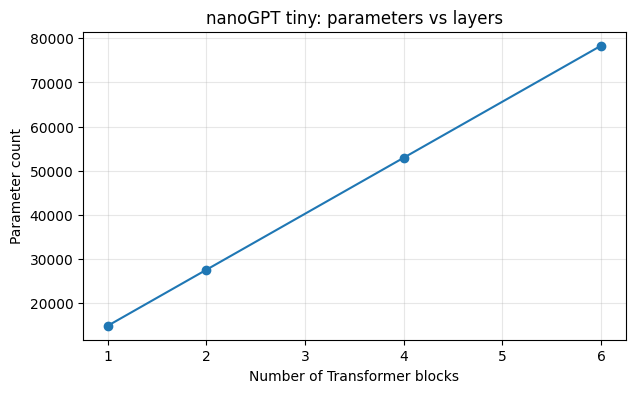

n_layer=1: params=14,816
n_layer=2: params=27,520
n_layer=4: params=52,928
n_layer=6: params=78,336
观察：层数越多，Block 里的 Attention 和 MLP 参数会近似线性增加。


In [8]:
# 实验 1：层数增加时，nanoGPT 参数量怎么变
layer_counts = [1, 2, 4, 6]
nano_param_counts = []

for n_layer in layer_counts:
    cfg = NanoGPTConfig(
        block_size=16,
        vocab_size=64,
        n_layer=n_layer,
        n_head=2,
        n_embd=32,
        dropout=0.0,
        bias=True,
    )
    model = NanoGPT(cfg)
    nano_param_counts.append(model.get_num_params())

plt.figure(figsize=(7, 4))
plt.plot(layer_counts, nano_param_counts, marker="o")
plt.xlabel("Number of Transformer blocks")
plt.ylabel("Parameter count")
plt.title("nanoGPT tiny: parameters vs layers")
plt.grid(True, alpha=0.3)
plt.show()

for n_layer, params in zip(layer_counts, nano_param_counts):
    print(f"n_layer={n_layer}: params={params:,}")

print("观察：层数越多，Block 里的 Attention 和 MLP 参数会近似线性增加。")


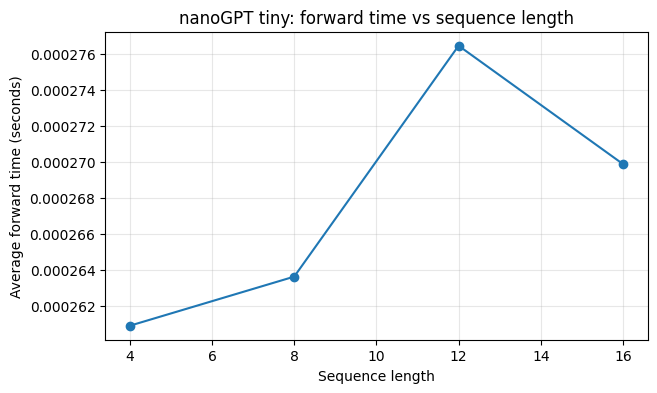

seq_len= 4: avg_forward_time=0.000261s
seq_len= 8: avg_forward_time=0.000264s
seq_len=12: avg_forward_time=0.000276s
seq_len=16: avg_forward_time=0.000270s
观察：Self-Attention 要看 token 两两关系，序列变长时计算通常会更贵。


In [9]:
# 实验 2：序列长度增加时，forward 时间怎么变
# 注意：CPU 上单次运行波动很大，所以每个长度跑多次取平均。
def benchmark_forward(model, seq_len, repeats=20):
    sample = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    target = torch.randint(0, nano_config.vocab_size, (2, seq_len))
    with torch.no_grad():
        model(sample, target)  # warmup
    start = time.perf_counter()
    with torch.no_grad():
        for _ in range(repeats):
            model(sample, target)
    elapsed = time.perf_counter() - start
    return elapsed / repeats

seq_lengths = [4, 8, 12, 16]
forward_times = []
for seq_len_value in seq_lengths:
    forward_times.append(benchmark_forward(nano_model, seq_len_value))

plt.figure(figsize=(7, 4))
plt.plot(seq_lengths, forward_times, marker="o")
plt.xlabel("Sequence length")
plt.ylabel("Average forward time (seconds)")
plt.title("nanoGPT tiny: forward time vs sequence length")
plt.grid(True, alpha=0.3)
plt.show()

for seq_len_value, seconds in zip(seq_lengths, forward_times):
    print(f"seq_len={seq_len_value:2d}: avg_forward_time={seconds:.6f}s")

print("观察：Self-Attention 要看 token 两两关系，序列变长时计算通常会更贵。")


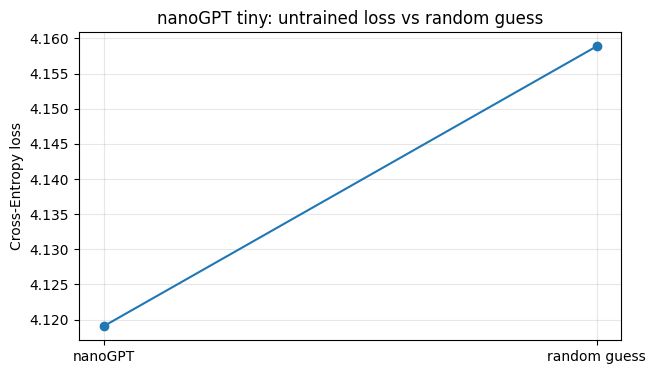

nanoGPT loss:       4.1190
random guess loss:  4.1589
观察：没训练的 GPT，loss 接近随机猜测水平。这是正常的。


In [10]:
# 实验 3：nanoGPT 随机初始化 loss 与随机猜测水平
# 模型还没训练，所以 loss 应该接近 log(vocab_size)。
torch.manual_seed(123)
compare_idx = torch.randint(0, 64, (4, 12))
compare_targets = torch.randint(0, 64, (4, 12))

with torch.no_grad():
    compare_logits, compare_loss = nano_model(compare_idx, compare_targets)

random_guess_loss = math.log(64)
losses = [compare_loss.item(), random_guess_loss]
names = ["nanoGPT", "random guess"]

plt.figure(figsize=(7, 4))
plt.plot(names, losses, marker="o")
plt.ylabel("Cross-Entropy loss")
plt.title("nanoGPT tiny: untrained loss vs random guess")
plt.grid(True, alpha=0.3)
plt.show()

print(f"nanoGPT loss:       {compare_loss.item():.4f}")
print(f"random guess loss:  {random_guess_loss:.4f}")
print("观察：没训练的 GPT，loss 接近随机猜测水平。这是正常的。")


## 8. 手写版与 nanoGPT 对照

通过前面的实验，把手写版和 nanoGPT 的对应关系再放在一起：

| 教学版 | nanoGPT | 意义 |
|:---|:---|:---|
| `MiniGPT` | `GPT` | 整台模型 |
| `TransformerBlock` | `Block` | 一层 decoder block |
| `MultiHeadAttention` | `CausalSelfAttention` | causal self-attention |
| `FeedForward` | `MLP` | token 内部的非线性加工 |
| `token_emb` | `transformer.wte` | token embedding |
| `pe` / position | `transformer.wpe` | position embedding |
| `lm_head` | `lm_head` | hidden state → vocab logits |

读真实工程代码时，建议沿着 `GPT.forward` 走。只要这条主线清楚，训练脚本里的工程细节（optimizer、checkpoint、learning rate schedule 等）就不会造成混乱。

## 9. Special Tokens

MiniGPT 能输出 logits 了，但在实际使用中，模型还需要一些"边界符号"来标记序列的结构。

比如：序列从哪里开始、到哪里结束、哪些位置只是用来补齐长度的。在一些场景中，模型还需要区分"思考过程"和"最终回答"。这些特殊标记统称为 special tokens：

```text
<BOS>       begin of sequence，标记序列的开始
<EOS>       end of sequence，标记序列的结束，生成时遇到它就停止
<PAD>       padding，用来补齐长度，标记这个位置不是真实内容
<think>     thinking start，标记下面进入思考区间
</think>    thinking end，标记思考区间结束，下面给最终回答
```

需要注意的是，`<think>` 不会让模型自动变聪明。它只是一个符号——模型要学会正确使用它，训练数据里必须反复出现这种格式。

In [11]:
# 演示：给 Mini-GPT 的词表加入新的 special tokens
base_vocab = {
    "用户": 0,
    "助手": 1,
    "答案": 2,
    "357": 3,
    "289": 4,
    "103173": 5,
}

special_tokens = ["<BOS>", "<EOS>", "<PAD>", "<think>", "</think>"]

vocab = base_vocab.copy()
for token in special_tokens:
    if token not in vocab:
        vocab[token] = len(vocab)

print("新增后的 special token ID:")
for token in special_tokens:
    print(f"  {token:8s} -> {vocab[token]}")

print()
print("关键观察：<think> 和 </think> 现在有独立 ID，")
print("模型才能把它们当成边界符号，而不是普通文字碎片。")

新增后的 special token ID:
  <BOS>    -> 6
  <EOS>    -> 7
  <PAD>    -> 8
  <think>  -> 9
  </think> -> 10

关键观察：<think> 和 </think> 现在有独立 ID，
模型才能把它们当成边界符号，而不是普通文字碎片。


In [12]:
# 演示：一条带 <think> 的训练样本长什么样
sample_tokens = [
    "<BOS>",
    "用户",
    "357",
    "289",
    "助手",
    "<think>",
    "357",
    "289",
    "103173",
    "</think>",
    "答案",
    "103173",
    "<EOS>",
]

sample_ids = [vocab[token] for token in sample_tokens]

print("训练样本 token:")
print(sample_tokens)
print()
print("训练样本 ID:")
print(sample_ids)
print()
print("关键观察：训练数据里出现这种格式，模型才会学会什么时候开始想、什么时候结束想。")

训练样本 token:
['<BOS>', '用户', '357', '289', '助手', '<think>', '357', '289', '103173', '</think>', '答案', '103173', '<EOS>']

训练样本 ID:
[6, 0, 3, 4, 1, 9, 3, 4, 5, 10, 2, 5, 7]

关键观察：训练数据里出现这种格式，模型才会学会什么时候开始想、什么时候结束想。


新增 special tokens 后，词表变大了。词表一变大，Embedding 表也要跟着扩容，因为每个 token 都要有自己的向量。

In [13]:
# 用小矩阵演示：新增 token 后，Embedding 为什么要扩容
old_vocab_size = len(base_vocab)
new_vocab_size = len(vocab)
d_model = 8

torch.manual_seed(42)
old_embedding = nn.Embedding(old_vocab_size, d_model)
new_embedding = nn.Embedding(new_vocab_size, d_model)

# 旧 token 的向量复制过去，新 token 的向量保留随机初始化，后续训练会更新它们
with torch.no_grad():
    new_embedding.weight[:old_vocab_size] = old_embedding.weight

print(f"旧词表大小: {old_vocab_size}")
print(f"新词表大小: {new_vocab_size}")
print(f"Embedding 形状: {tuple(new_embedding.weight.shape)}")
print()
print("关键观察：新增 5 个 special tokens 后，Embedding 也多了 5 行。")
print("这些新行要靠后续训练，才会学到 <think>、</think> 的真正用途。")

旧词表大小: 6
新词表大小: 11
Embedding 形状: (11, 8)

关键观察：新增 5 个 special tokens 后，Embedding 也多了 5 行。
这些新行要靠后续训练，才会学到 <think>、</think> 的真正用途。


## 小结

这一节所学的内容：

- GPT = Embedding + Position + 多层 Transformer Block + LayerNorm + 输出投影
- 中间 hidden state 的形状保持 `[batch, seq, d_model]`，只有最后一步变成 vocab_size
- logits 是每个位置对词表中所有 token 的打分，分数越高表示模型越倾向于预测该 token
- 手写版和 nanoGPT 在结构上一致，只是工程代码多了 weight tying、可学习 position embedding 等细节
- special tokens 需要独立 ID，也需要相应扩容 Embedding 表

下一节进入训练：loss 怎么算，模型怎么从随机初始化变成能生成有意义文本的状态。

## 作业

这道题检查对生成时 temperature 参数的理解。

> **关于 AI 辅助**：可以让 AI 解释 temperature 对概率分布的影响，但请自己写出缩放 logits 的那一行代码。

**作业 1：temperature 调整 logits**

现代 LLM 生成时经常用 temperature 控制随机性。temperature 越小，分布越尖锐（更确定）；越大，分布越平（更随机）。

**小提示**：常见写法是 `scaled_logits = logits / temperature`。

In [ ]:
# 作业 1：temperature 缩放 logits 填空
import torch

logits = torch.tensor([1.0, 2.0, 3.0])
temperature = 0.5

# TODO：用 temperature 缩放 logits
scaled_logits = """在这里缩放 logits"""

assert not isinstance(scaled_logits, str), "请先替换三引号里的占位内容"
assert torch.allclose(scaled_logits, torch.tensor([2.0, 4.0, 6.0])), scaled_logits
print("✅ 作业 1 通过：temperature < 1 会让 logits 差距变大，分布更尖锐")


## 参考资料

- Vaswani et al., [Attention Is All You Need](https://arxiv.org/abs/1706.03762), 2017 — Transformer 原始论文（Encoder-Decoder 架构），GPT 是其 Decoder-Only 变体
- Harvard NLP, [The Annotated Transformer](https://nlp.seas.harvard.edu/annotated-transformer/) — 原始 Encoder-Decoder Transformer 的逐行实现，可作为"完整对照"阅读：理解原始架构的 Encoder/Decoder/Cross-Attention，再对比本文的 Decoder-Only 设计
- Karpathy, [nanoGPT](https://github.com/karpathy/nanoGPT) — 本节对照的工程实现
- Radford et al., [Language Models are Unsupervised Multitask Learners](https://d4mucfpksywv.cloudfront.net/better-language-models/language-models.pdf), 2019 — GPT-2 论文